In [6]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Assignment 2:  Nearest k Neighbor**


**Q1. Please answer the following questions.**

1. What is the difference between regression and classification?

A regression is used when the variable you are interested is continuous, which basically means that it is a numeric value. For example, temperature. A classification on ther other hand, is used when the variable you are interested is categorical, which means we are using a label like valid or invalid.

2.What is a confusion table/matrix? What does it help us understand about a model's performance?

A confusion matrix is a table that compares predicted class labels to actual class labels. Each column shows the predicted class and each row shows the true class. It helps us understand a model's performance by showing which specific classes are misclassified. It can help us understand common patterns of error and the predictability of classes.

3.What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?

Accuracy is the proportion of correct predictions out of all predictions made. Accuracy can be misleading especially when the dataset is imbalanced. The issue is it doesn't tell the entire story about how the model makes mistakes. The model can appear to perform well by predicting the majority class most of the time, but the model can perform poorly on the miniority class, which could be the most important one.


4.What does the root mean squared error quantify about a particular model?

Root Mean Squared Error measures the size of prediction errors in a regression. It can show us on average how far predictions are from true values. It also punishes large errors at a higher rate than smaller ones because the errors are squared before the averaging.

5.What are overfitting and underfitting?

Overfitting is when a model is very complex and performs well on training data but bad on new data. Underfitting is when a model is very simple, almost too simple, to capture the structure in the data. It does bad on test and training data.

6.Why does splitting the data into training and testing sets, and choosing  by evaluating accuracy or RMSE on the test set, improve model performance?

Splitting the data into training and test sets allows you to evaluate how well the model can generalize new data. This can help prevent overfitting due to the fact that we are not giving the model the same data used to evaluate it.


7.With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Predicting class labels can give you a direction decision. The pros to this is that it is easy to use and simple, but it doesn't show how confident the model truly is. Predicting probabilities can give you more information about uncertainty, which can help you with risk senesitive decision making, but it's often harder to interpret.

**Q2. This is a case study on  nearest neighbor classification, using the land_mines.csv data.**

The data consists of a label, mine_type, taking integer values 1 to 5, and three properties of the mine, voltage, height and soil. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).


2.Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)


3.Build a k-NN classifier. Explain how you select k.


4.Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?


5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

**Step 1**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [3]:
df = pd.read_csv("./data/land_mines.csv")
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [4]:
df["mine_type"].value_counts().sort_index()

,count
mine_type,
1,71
2,70
3,66
4,66
5,65


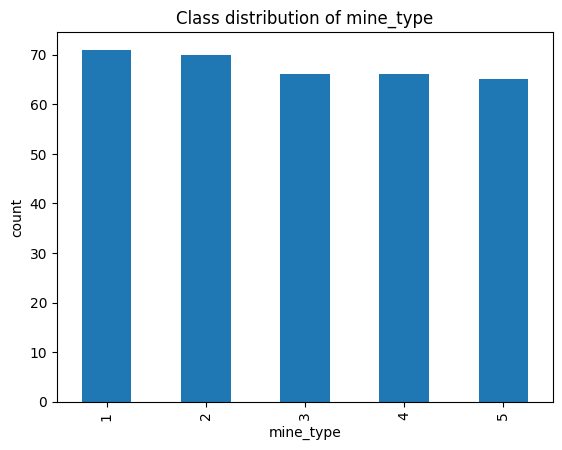

In [5]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("mine_type")
plt.ylabel("count")
plt.title("Class distribution of mine_type")
plt.show()

In [6]:
df[["voltage","height","soil"]].describe()

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


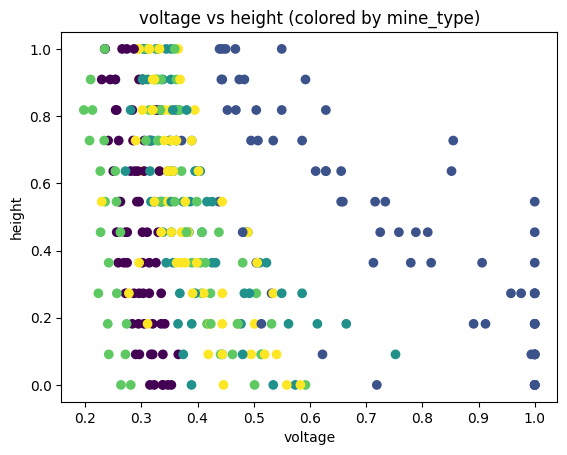

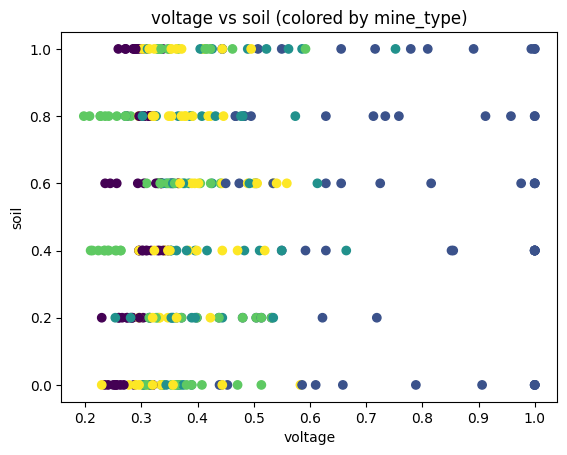

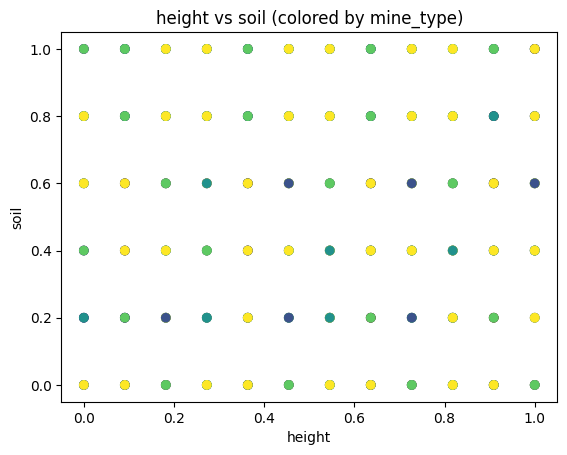

In [7]:
plt.figure()
plt.scatter(df["voltage"], df["height"], c=df["mine_type"])
plt.xlabel("voltage"); plt.ylabel("height")
plt.title("voltage vs height (colored by mine_type)")
plt.show()

plt.figure()
plt.scatter(df["voltage"], df["soil"], c=df["mine_type"])
plt.xlabel("voltage"); plt.ylabel("soil")
plt.title("voltage vs soil (colored by mine_type)")
plt.show()

plt.figure()
plt.scatter(df["height"], df["soil"], c=df["mine_type"])
plt.xlabel("height"); plt.ylabel("soil")
plt.title("height vs soil (colored by mine_type)")
plt.show()


**2.**

In [8]:
X = df[["voltage","height","soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label counts:\n", y_train.value_counts().sort_index())
print("Test label counts:\n", y_test.value_counts().sort_index())


Train: (169, 3) Test: (169, 3)
Train label counts:
 mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
Test label counts:
 mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


In [9]:
train_mins = X_train.min()
train_maxs = X_train.max()
denom = (train_maxs - train_mins).replace(0, 1)

X_train_s = (X_train - train_mins) / denom
X_test_s  = (X_test  - train_mins) / denom

**3.**

In [10]:
k_grid = [1, 3, 5, 7, 9, 11, 15, 25, 35]

results = []
best_k = None
best_acc = -1
best_model = None

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, pred)
    results.append((k, acc))

    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_model = model

results_df = pd.DataFrame(results, columns=["k", "accuracy"]).sort_values("accuracy", ascending=False)
results_df


,k,accuracy
0,1,0.461538
1,3,0.384615
6,15,0.384615
5,11,0.378698
4,9,0.372781
7,25,0.372781
8,35,0.366864
2,5,0.355030
3,7,0.337278


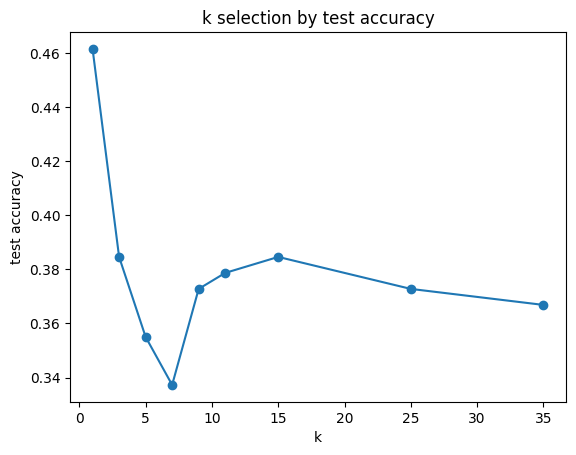

Best k: 1 Best test accuracy: 0.46153846153846156


In [11]:
plt.figure()
plt.plot([r[0] for r in results], [r[1] for r in results], marker="o")
plt.xlabel("k")
plt.ylabel("test accuracy")
plt.title("k selection by test accuracy")
plt.show()

print("Best k:", best_k, "Best test accuracy:", best_acc)

We can select k by comparing the test accuracy across candidate values and choose the k that maximizes it the best. It seems that k = 1 gives us the highest test accuracy at about 46%, which makes it the most optimal choice. This plot shows the bias variance trade off in kNN. The are very small values of k that allow the model to be flexible and follow pattersn within the data. This can improve the accuracy but could also lead to overfitting. We can see that as k increases, the accuracy declines because of underfitting.

**4.**

In [12]:
best_pred = best_model.predict(X_test_s)

acc = accuracy_score(y_test, best_pred)
print("Test accuracy:", acc)

labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)
cm

Test accuracy: 0.46153846153846156


array([[21,  0,  4,  4,  7],
       [ 0, 32,  0,  3,  0],
       [ 8,  0,  7, 10,  8],
       [ 7,  5,  4, 11,  6],
       [ 7,  0,  9,  9,  7]])

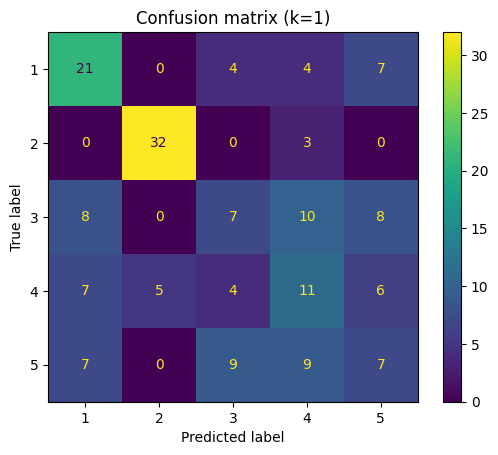

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title(f"Confusion matrix (k={best_k})")
plt.show()

In [14]:
per_class_acc = (cm.diagonal() / cm.sum(axis=1))
pd.DataFrame({"mine_type": labels, "per_class_accuracy": per_class_acc})

,mine_type,per_class_accuracy
0,1,0.583333
1,2,0.914286
2,3,0.212121
3,4,0.333333
4,5,0.218750


The confusion matrix shows an overall accuracy of about 46%, so the model is right about a little less than half the time.This can leave a lot of room for error. This model does best on mine type 2, which is actually predicted correctly most of the time. Mine type 1 is alright, but types 3, 4, and 5 struggles. This means that those mine types have similar soil readings, height, and voltage. Because of this, the model has a hard time telling them apart. Performance seems to drop when different types look similar in the data, but overall the classifier works better when a mine type has a distinct feature.

**5.**

In [15]:
df[["voltage", "height", "soil"]].describe()

,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


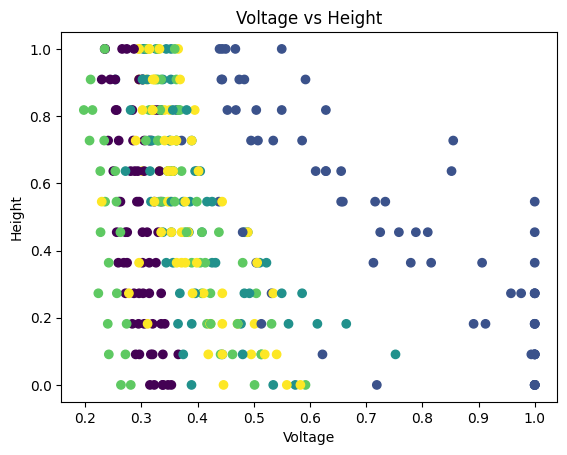

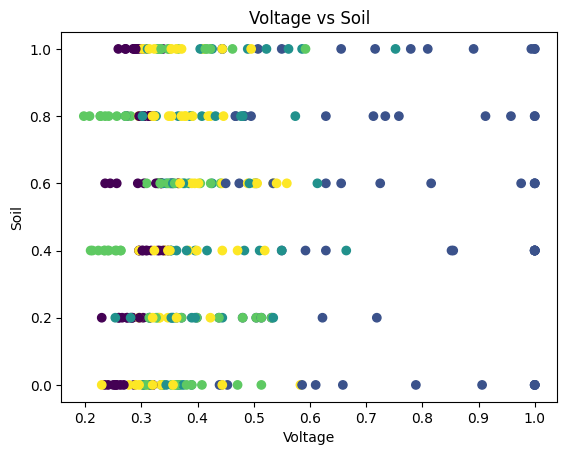

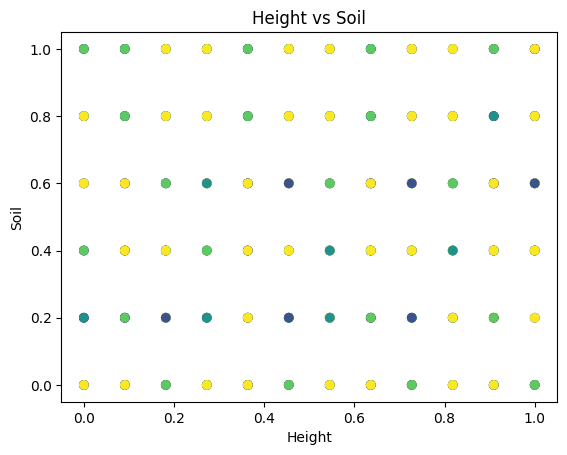

In [16]:
plt.scatter(df["voltage"], df["height"], c=df["mine_type"])
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.title("Voltage vs Height")
plt.show()

plt.scatter(df["voltage"], df["soil"], c=df["mine_type"])
plt.xlabel("Voltage")
plt.ylabel("Soil")
plt.title("Voltage vs Soil")
plt.show()

plt.scatter(df["height"], df["soil"], c=df["mine_type"])
plt.xlabel("Height")
plt.ylabel("Soil")
plt.title("Height vs Soil")
plt.show()

Even though the model makes many correct predictions for some mine types, it still makes a lot of mistakes, especially between types that look similar. Because of this, the model should not be used a final decision maker in the field. Instead it should be used as a tool to help you make a decision. The prediction can give operators an idea of what type of mine they may be dealing with, but it should also look the confidence of the model. If the model is unsure or if the mine type is one that the confusion matrix misclassifies, then it should be treated with caution and checked. This model is useful for narrowing down possibilities and flagging high risk cases, but it shouldn't replace our judgement.

**Q3. This question is a case study for **k** nearest neighbor regression, using the USA_cars_datasets.csv data.**

The target variable y is price and the features are year and mileage.

1. Load the ./data/USA_cars_datasets.csv. Keep the following variables and drop the rest: price, year, mileage. Are there any NA's to handle? Look at the head and dimensions of the data.



2. Maxmin normalize year and mileage.



3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.



4. Use the -NN algorithm and the training data to predict price using year and mileage for the test set for k=3, 10, 25, 50, 100, 300. For each value of , compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase k?



5.Determine the optimal k for these data.



6.Describe what happened in the plots of predicted versus actual prices as k varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

**1.**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv("./data/USA_cars_datasets.csv")

df = df[["price", "year", "mileage"]]

df.head(), df.shape, df.isna().sum()

(   price  year  mileage
 0   6300  2008   274117
 1   2899  2011   190552
 2   5350  2018    39590
 3  25000  2014    64146
 4  27700  2018     6654,
 (2499, 3),
 price      0
 year       0
 mileage    0
 dtype: int64)

The data has 2,499 observations and 3 variables. The variables are numeric and correctly formatted. All 3 variables have 0 missing values, therefore, there are no NA values to handle.

In [20]:
X = df[["year", "mileage"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

mins = X_train.min()
maxs = X_train.max()
denom = (maxs - mins).replace(0, 1)

X_train_s = (X_train - mins) / denom
X_test_s = (X_test - mins) / denom

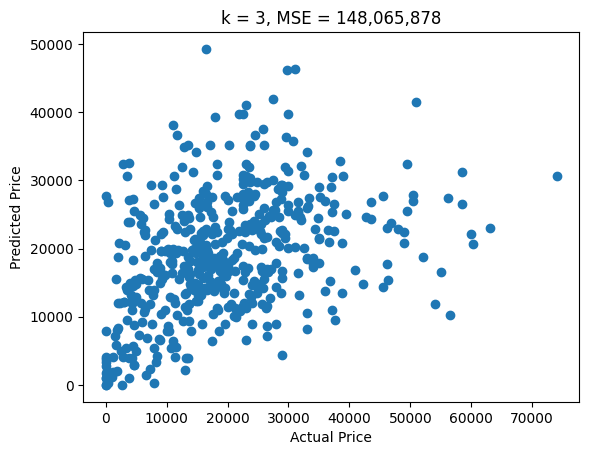

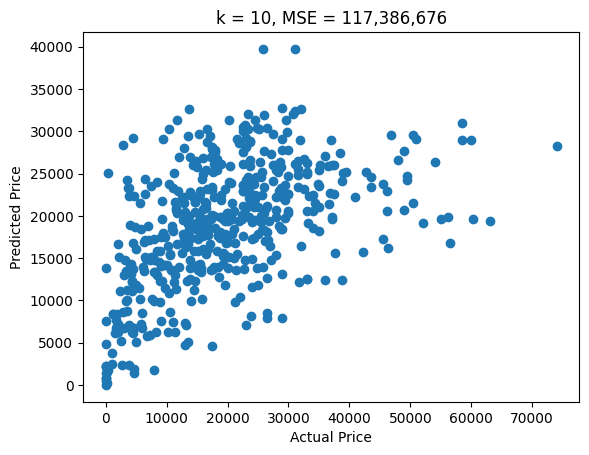

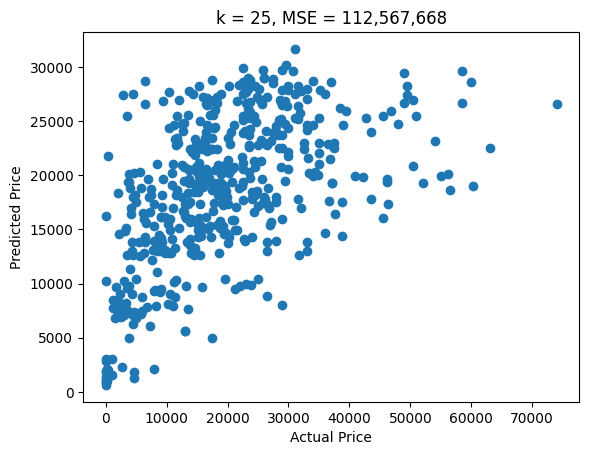

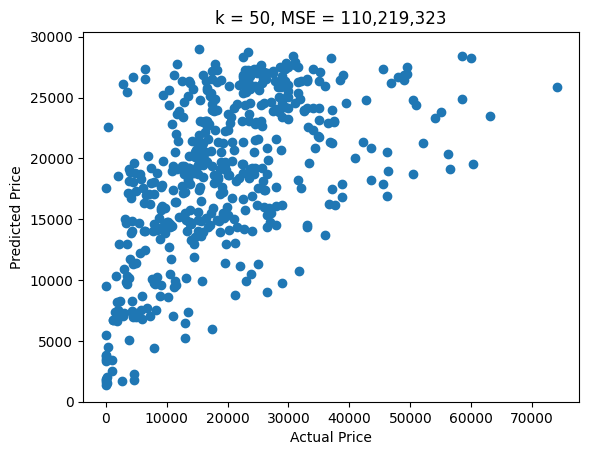

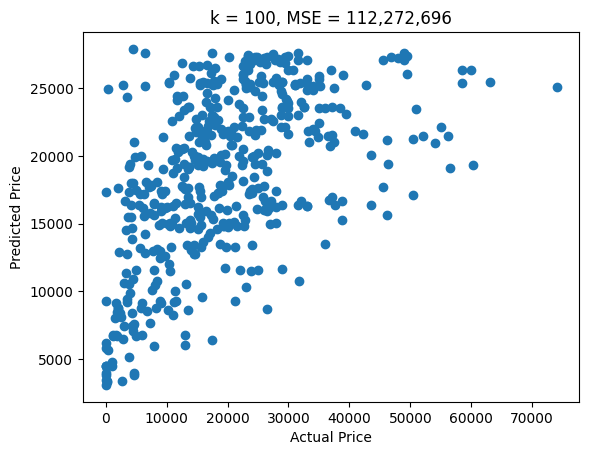

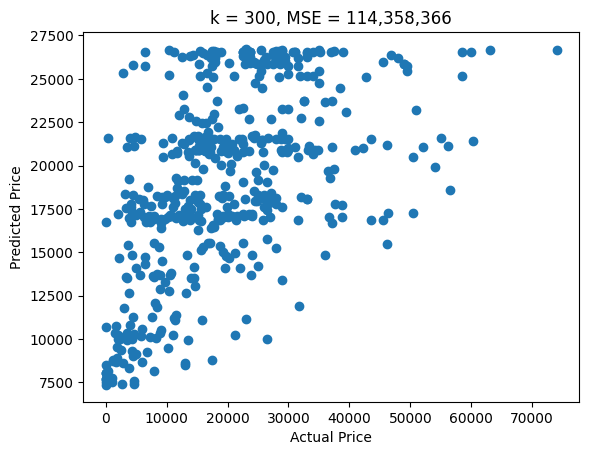

,k,MSE
3,50,1.102193e+08
4,100,1.122727e+08
2,25,1.125677e+08
5,300,1.143584e+08
1,10,1.173867e+08
0,3,1.480659e+08


In [21]:
k_values = [3, 10, 25, 50, 100, 300]
mse_list = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)

    mse = mean_squared_error(y_test, preds)
    mse_list.append(mse)

    plt.figure()
    plt.scatter(y_test, preds)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k = {k}, MSE = {mse:,.0f}")
    plt.show()

results = pd.DataFrame({"k": k_values, "MSE": mse_list})
results.sort_values("MSE")

As k increases, the model's behavior changes in a clear way. With small k=3, the predictions are spread out and follow individual data points closely. This leads to higher MSE, suggesting that the model is overfitting and reacting too much to noise in the training data. As k moves to moderate values, the predictions line up better with the trend in prices and the MSE seems to drop. The model does it's best here. When k gets bigger, the predictions become very similar to one another and cluster around the middle price range. The model starts missing very cheap and expensive cars, which increases our error. This is underfitting and the model is too simnple to capture a real pattern.

The optimal k is 50, because it gives the lowest mean squared error on the test set of data. This basicallly means that it produces the most accurate predictions compared to the other values that are tested.

Like I said before, When k was small (like 3), the predictions were spread out and followed individual data points closely. This led to higher error and is a sign of overfitting, where the model is too sensitive to noise in the training data.
As k increased to around 25–50, the predictions became more stable and lined up better with the overall trend between actual and predicted prices. This reduced error and shows a good balance between flexibility and smoothing.
When k became very large (100 or 300), the predictions started clustering around the middle price range and missed extreme values. This increased error again and shows underfitting, where the model is too simple to capture important patterns in the data.

**Q6. This is a case study using k nearest neighbor regression for imputation, using the airbnb_hw.csv data.**

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.


1. Load the airbnb_hw.csv data with Pandas. We're only going to use Review Scores Rating, Price, and Beds, so use .loc to column filter the dataframe to those variables.


2. Set use .isnull() and .loc to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.


3. Use df = df.dropna(axis = 0, how = 'any') to eliminate any observations with missing values/NA's from the dataframe.


4. For the complete cases, create a k-NN model that uses the variables Price and Beds to predict Review Scores Rating. How do you choose k? (Hint: Train/test split, iterate over reasonable values of k and find a value that minimizes SSE on the test split using predictions from the training set.)


5. Predict the missing ratings.


6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**1.**

In [27]:
df["Price"] = df["Price"].replace('[\$,]', '', regex=True).astype(float)

df["Beds"] = pd.to_numeric(df["Beds"], errors="coerce")

df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

df.dtypes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

df = pd.read_csv("./data/airbnb_hw.csv")
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]

df["Price"] = df["Price"].astype(str).replace(r"[\$,]", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Beds"] = pd.to_numeric(df["Beds"], errors="coerce")
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

df.head(), df.shape, df.isna().sum()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3449214690.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Price"] = df["Price"].replace('[\$,]', '', regex=True).astype(float)


(   Review Scores Rating  Price  Beds
 0                   NaN    145   1.0
 1                   NaN     37   1.0
 2                   NaN     28   1.0
 3                   NaN    199   3.0
 4                  96.0    549   3.0,
 (30478, 3),
 Review Scores Rating    8323
 Price                      0
 Beds                      85
 dtype: int64)

**2.**

In [28]:
missing_df = df.loc[df["Review Scores Rating"].isnull()].copy()
print("Missing-rating rows:", missing_df.shape[0])
missing_df.head()


Missing-rating rows: 8323


,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
13,NaN,68,1.0


**3.**

In [29]:
df_model = df.dropna(axis=0, how="any").copy()
df_model.shape

(22111, 3)

**4.**

In [30]:
X = df_model[["Price", "Beds"]]
y = df_model["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

mins = X_train.min()
maxs = X_train.max()
denom = (maxs - mins).replace(0, 1)

X_train_s = (X_train - mins) / denom
X_test_s = (X_test - mins) / denom

k_values = [3, 5, 10, 25, 50, 100, 200, 300]
results = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    sse = np.sum((y_test - preds) ** 2)
    results.append((k, sse))

results_df = pd.DataFrame(results, columns=["k", "SSE"]).sort_values("SSE")
results_df

,k,SSE
7,300,315378.634567
6,200,315574.202650
5,100,315743.609900
4,50,321595.606400
3,25,328064.366400
2,10,346636.990000
1,5,404836.240000
0,3,486794.000000


To choose the value of k, I used a train/test split and tried several reasonable values of k. For each value, I trained a k-NN regressor on the training data and calculated the sum of squared errors on the test set. I then selected the value of k that produced the lowest sum of squared error. That means the preductions were closest to the true ratings on the unseen data and based on the results, k=300 which gives the smallest SSE, so that is the optimal choice.

**5.**

In [33]:
best_k = int(results_df.iloc[0]["k"])

final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train_s, y_train)

X_missing = missing_df[["Price", "Beds"]]

valid_mask = X_missing.notna().all(axis=1)
X_missing_valid = X_missing.loc[valid_mask].copy()

X_missing_valid_s = (X_missing_valid - mins) / denom

missing_df["Imputed Rating"] = np.nan
missing_df.loc[valid_mask, "Imputed Rating"] = final_model.predict(X_missing_valid_s)

print("Missing-rating rows total:", len(missing_df))
print("Rows we could impute (Price & Beds present):", valid_mask.sum())
print("Rows still not imputed (Price or Beds missing):", (~valid_mask).sum())

missing_df.head(10)



Missing-rating rows total: 8323
Rows we could impute (Price & Beds present): 8282
Rows still not imputed (Price or Beds missing): 41


,Review Scores Rating,Price,Beds,Imputed Rating
0,NaN,145,1.0,93.490000
1,NaN,37,1.0,87.883333
2,NaN,28,1.0,88.023333
3,NaN,199,3.0,89.850000
13,NaN,68,1.0,91.813333
19,NaN,700,3.0,92.270000
21,NaN,175,1.0,93.390000
22,NaN,90,1.0,92.240000
29,NaN,99,4.0,89.333333
30,NaN,99,1.0,91.943333


**6.**

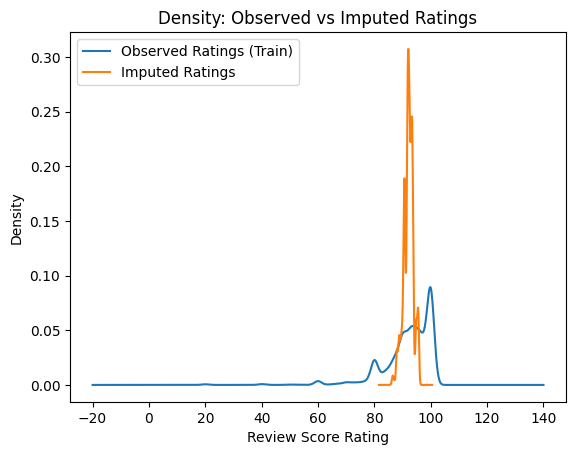

In [34]:
plt.figure()
pd.Series(y_train).plot(kind="kde", label="Observed Ratings (Train)")
missing_df["Imputed Rating"].plot(kind="kde", label="Imputed Ratings")
plt.xlabel("Review Score Rating")
plt.title("Density: Observed vs Imputed Ratings")
plt.legend()
plt.show()


The two distributions are similar in location but not in shape. Both the observed and imputed ratings are concentrated in the high rating range. That makes sense because most Airbnb listings have high reviews. But, the imputed ratings are more clustered and have sharp peak, while the observed have more spread and variability. This happens because kNN predictions are based on averaging nearby values, whicvh smooths out extremes/outliers and reduces variation. All in all, the imputed ratings are less scattered and more centered around the typical rating compared to observed data.